# Εργαστήριο 8 — Γενετικοί Αλγόριθμοι (Genetic Algorithms)

**Μάθημα:** Ευφυή Συστήματα και Συστήματα Υποστήριξης Αποφάσεων  
**Πανεπιστήμιο Δυτικής Αττικής (ΠΑΔΑ)**

---

## Στόχοι Εργαστηρίου

Σε αυτό το εργαστήριο θα:

- Υλοποιήσουμε τους βασικούς τελεστές ενός **Γενετικού Αλγορίθμου (GA)** από μηδέν
- Επιλύσουμε πρόβλημα αριθμητικής βελτιστοποίησης (**f(x) = x²**, Goldberg 1989)
- Εφαρμόσουμε GA στο **Πρόβλημα Σακιδίου (0/1 Knapsack)**
- Εφαρμόσουμε GA στο **Πρόβλημα Πλανόδιου Πωλητή (TSP)** με Ordered Crossover (OX)
- Οπτικοποιήσουμε τη **σύγκλιση** του αλγορίθμου ανά γενιά
- Συγκρίνουμε την επίδραση των **υπερπαραμέτρων** (μέγεθος πληθυσμού, mutation rate)

---

## Απαιτούμενες Βιβλιοθήκες

| Βιβλιοθήκη | Χρήση |
|---|---|
| `numpy` | Αριθμητικές πράξεις, αποστάσεις |
| `matplotlib` | Οπτικοποίηση σύγκλισης και διαδρομών |
| `random` | Τυχαία αρχικοποίηση, επιλογή, μετάλλαξη |
| `pandas` | Εμφάνιση πινάκων αποτελεσμάτων |

```bash
pip install numpy matplotlib pandas
```

In [1]:
pip install numpy matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

print('✓ Όλες οι βιβλιοθήκες φορτώθηκαν επιτυχώς.')

✓ Όλες οι βιβλιοθήκες φορτώθηκαν επιτυχώς.


---

## 1. Βασικοί Τελεστές Γενετικού Αλγορίθμου

Πριν τρέξουμε οποιοδήποτε παράδειγμα, υλοποιούμε τις βασικές δομικές μονάδες:

| Συνάρτηση | Τελεστής | Ρόλος |
|---|---|---|
| `decode_binary` | — | Μετατρέπει δυαδικό χρωμόσωμα `[1,0,1,…]` → ακέραιο x |
| `roulette_selection` | Επιλογή | Επιλέγει γονέα ανάλογα με fitness (τροχός ρουλέτας) |
| `single_point_crossover` | Crossover | Ανταλλαγή γενετικού υλικού σε ένα τυχαίο σημείο |
| `bit_flip_mutation` | Mutation | Αντιστροφή bits με πιθανότητα `p_mut` |

Αυτές οι συναρτήσεις θα χρησιμοποιηθούν αυτούσιες στα Παραδείγματα 1 και 2.

In [3]:
# ── Βασικοί τελεστές GA (δυαδική κωδικοποίηση) ────────────────────────────

def decode_binary(chromosome):
    """Μετατρέπει δυαδική λίστα [1,0,1,…] σε ακέραιο."""
    return int(''.join(map(str, chromosome)), 2)


def roulette_selection(population, fitnesses):
    """Επιλέγει ένα άτομο με πιθανότητα ανάλογη του fitness του."""
    total = sum(fitnesses)
    if total == 0:
        return random.choice(population)
    probs = [f / total for f in fitnesses]
    return random.choices(population, weights=probs, k=1)[0]


def single_point_crossover(p1, p2):
    """Single-point crossover — επιστρέφει δύο παιδιά."""
    point = random.randint(1, len(p1) - 1)
    c1 = p1[:point] + p2[point:]
    c2 = p2[:point] + p1[point:]
    return c1, c2


def bit_flip_mutation(chromosome, p_mut=0.05):
    """Αντιστρέφει κάθε bit με πιθανότητα p_mut."""
    return [1 - b if random.random() < p_mut else b for b in chromosome]


# ── Γρήγορος έλεγχος ──────────────────────────────────────────────────────
chrom = [0, 1, 1, 0, 1]  # 0*16 + 1*8 + 1*4 + 0*2 + 1*1 = 13
x = decode_binary(chrom)
print(f'Χρωμόσωμα       : {chrom}')
print(f'Αποκωδικοποίηση : x = {x}   (αναμένεται 13)')
print(f'Fitness f(x)=x² : {x**2}  (αναμένεται 169)')

print()
p1 = [1, 0, 0, 1, 1]
p2 = [0, 1, 1, 0, 0]
random.seed(1)
c1, c2 = single_point_crossover(p1, p2)
print(f'Crossover  P1={p1}  P2={p2}')
print(f'  → Παιδί 1: {c1}')
print(f'  → Παιδί 2: {c2}')

Χρωμόσωμα       : [0, 1, 1, 0, 1]
Αποκωδικοποίηση : x = 13   (αναμένεται 13)
Fitness f(x)=x² : 169  (αναμένεται 169)

Crossover  P1=[1, 0, 0, 1, 1]  P2=[0, 1, 1, 0, 0]
  → Παιδί 1: [1, 0, 1, 0, 0]
  → Παιδί 2: [0, 1, 0, 1, 1]


---

## 2. Παράδειγμα 1 — Μεγιστοποίηση f(x) = x²

**Πρόβλημα:** Εύρεση ακέραιου $x \in \{0, \ldots, 31\}$ που μεγιστοποιεί $f(x) = x^2$.  
Η βέλτιστη απάντηση είναι **x = 31**, f(31) = 961.

**Κωδικοποίηση:** Κάθε άτομο = **5-bit δυαδικό χρωμόσωμα** (Goldberg, 1989).  
Παράδειγμα: `01101` → $0{\times}16 + 1{\times}8 + 1{\times}4 + 0{\times}2 + 1{\times}1 = 13$, $f(13)=169$.

| Χρωμόσωμα | Αποκωδ. x | f(x) = x² | P(επιλογής) ≈ |
|:---:|:---:|:---:|:---:|
| `01101` | 13 | 169 | 14,4% |
| `11000` | 24 | 576 | 49,2% |
| `01000` | 8 | 64 | 5,5% |
| `10011` | 19 | 361 | 30,9% |

> **Πίεση Επιλογής:** Το Άτομο 2 έχει 3,4× μεγαλύτερο fitness από το Άτομο 1 → εμφανίζεται 3,4× πιο συχνά στην επόμενη γενιά.

In [4]:
# ── GA για f(x) = x² ──────────────────────────────────────────────────────

BITS       = 5    # μήκος χρωμοσώματος
POP_SIZE   = 10   # μέγεθος πληθυσμού
GENERATIONS = 25  # αριθμός γενιών
P_CROSS    = 0.8  # πιθανότητα crossover
P_MUT      = 0.05 # πιθανότητα μετάλλαξης ανά bit


def fitness_fx2(chromosome):
    return decode_binary(chromosome) ** 2


def run_ga_binary(pop_size=POP_SIZE, generations=GENERATIONS,
                  p_cross=P_CROSS, p_mut=P_MUT):
    # Αρχικός τυχαίος πληθυσμός
    population = [[random.randint(0, 1) for _ in range(BITS)]
                  for _ in range(pop_size)]

    best_per_gen = []
    avg_per_gen  = []

    for _ in range(generations):
        fitnesses = [fitness_fx2(ind) for ind in population]
        best_per_gen.append(max(fitnesses))
        avg_per_gen.append(sum(fitnesses) / len(fitnesses))

        # Ελιτισμός: το καλύτερο περνάει αυτόματα
        best_idx = fitnesses.index(max(fitnesses))
        new_pop = [population[best_idx][:]]

        while len(new_pop) < pop_size:
            p1 = roulette_selection(population, fitnesses)
            p2 = roulette_selection(population, fitnesses)
            if random.random() < p_cross:
                c1, c2 = single_point_crossover(p1, p2)
            else:
                c1, c2 = p1[:], p2[:]
            new_pop.append(bit_flip_mutation(c1, p_mut))
            new_pop.append(bit_flip_mutation(c2, p_mut))

        population = new_pop[:pop_size]

    fitnesses = [fitness_fx2(ind) for ind in population]
    best = population[fitnesses.index(max(fitnesses))]
    return best, best_per_gen, avg_per_gen


random.seed(42)
best_chrom, best_hist, avg_hist = run_ga_binary()
x_best = decode_binary(best_chrom)
print(f'Βέλτιστο χρωμόσωμα : {best_chrom}')
print(f'Αποκωδικοποίηση    : x = {x_best}')
print(f'Fitness            : f({x_best}) = {x_best**2}  (βέλτιστο: 961)')

Βέλτιστο χρωμόσωμα : [1, 1, 1, 1, 1]
Αποκωδικοποίηση    : x = 31
Fitness            : f(31) = 961  (βέλτιστο: 961)


In [5]:
# ── Αρχικός Πληθυσμός (Γενιά 0) — Goldberg 1989 ──────────────────────────

goldberg_pop = [
    [0, 1, 1, 0, 1],  # 13
    [1, 1, 0, 0, 0],  # 24
    [0, 1, 0, 0, 0],  # 8
    [1, 0, 0, 1, 1],  # 19
]

rows = []
total_fit = sum(decode_binary(c)**2 for c in goldberg_pop)
for c in goldberg_pop:
    x = decode_binary(c)
    f = x ** 2
    rows.append({
        'Χρωμόσωμα': ''.join(map(str, c)),
        'x': x,
        'f(x)=x²': f,
        'P(επιλογής)': f'{f/total_fit*100:.1f}%',
        'Αναμ. αντίγρ.': f'{f/total_fit*4:.2f}',
    })

df = pd.DataFrame(rows)
print('Αρχικός Πληθυσμός (Goldberg 1989):')
print(df.to_string(index=False))
print(f'\nΣύνολο fitness: {total_fit}')

Αρχικός Πληθυσμός (Goldberg 1989):
Χρωμόσωμα  x  f(x)=x² P(επιλογής) Αναμ. αντίγρ.
    01101 13      169       14.4%          0.58
    11000 24      576       49.2%          1.97
    01000  8       64        5.5%          0.22
    10011 19      361       30.9%          1.23

Σύνολο fitness: 1170


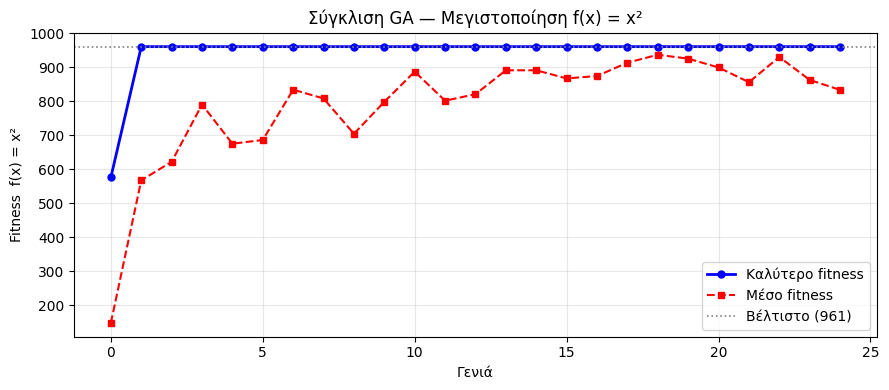

In [6]:
# ── Γράφημα Σύγκλισης f(x)=x² ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(best_hist, 'b-o', markersize=5, linewidth=2, label='Καλύτερο fitness')
ax.plot(avg_hist,  'r--s', markersize=4, linewidth=1.5, label='Μέσο fitness')
ax.axhline(961, color='gray', linestyle=':', linewidth=1.2, label='Βέλτιστο (961)')
ax.set_xlabel('Γενιά')
ax.set_ylabel('Fitness  f(x) = x²')
ax.set_title('Σύγκλιση GA — Μεγιστοποίηση f(x) = x²')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 3. Παράδειγμα 2 — Πρόβλημα Σακιδίου (0/1 Knapsack)

**Πρόβλημα:** Επιλέξτε αντικείμενα που χωρούν σε σακίδιο **χωρητικότητας 10 kg**,  
μεγιστοποιώντας τη **συνολική αξία (€)**.

**Κωδικοποίηση:** Κάθε άτομο = **δυαδικό χρωμόσωμα** μήκους 5 (ένα bit ανά αντικείμενο).  
`1` = επιλέγεται · `0` = αποκλείεται.  
Χρωμόσωμα `[1, 0, 1, 1, 0]` → Laptop + Κάμερα + Tablet = 10 kg, 19 €.

| Αντικείμενο | Βάρος (kg) | Αξία (€) | Αξία/kg |
|:---:|:---:|:---:|:---:|
| Laptop | 3 | 9 | 3,0 |
| Βιβλίο | 4 | 5 | 1,25 |
| Κάμερα | 2 | 7 | 3,5 |
| Tablet | 5 | 3 | 0,6 |
| Ρολόι | 1 | 4 | 4,0 |

**Fitness:** αξία αντικειμένων αν βάρος ≤ 10 kg, αλλιώς **0** (ποινή υπέρβασης).

In [7]:
# ── Ορισμός και επίλυση Knapsack ──────────────────────────────────────────

ITEMS = [
    {'name': 'Laptop',  'weight': 3, 'value': 9},
    {'name': 'Βιβλίο',  'weight': 4, 'value': 5},
    {'name': 'Κάμερα',  'weight': 2, 'value': 7},
    {'name': 'Tablet',  'weight': 5, 'value': 3},
    {'name': 'Ρολόι',   'weight': 1, 'value': 4},
]
MAX_WEIGHT = 10
N_ITEMS = len(ITEMS)


def fitness_knapsack(chromosome):
    total_w = sum(ITEMS[i]['weight'] for i in range(N_ITEMS) if chromosome[i] == 1)
    total_v = sum(ITEMS[i]['value']  for i in range(N_ITEMS) if chromosome[i] == 1)
    return total_v if total_w <= MAX_WEIGHT else 0


def run_ga_knapsack(pop_size=30, generations=50, p_cross=0.8, p_mut=0.1):
    population = [[random.randint(0, 1) for _ in range(N_ITEMS)]
                  for _ in range(pop_size)]
    best_per_gen = []

    for _ in range(generations):
        fitnesses = [fitness_knapsack(ind) for ind in population]
        best_per_gen.append(max(fitnesses))

        best_idx = fitnesses.index(max(fitnesses))
        new_pop = [population[best_idx][:]]

        while len(new_pop) < pop_size:
            p1 = roulette_selection(population, fitnesses)
            p2 = roulette_selection(population, fitnesses)
            if random.random() < p_cross:
                c1, c2 = single_point_crossover(p1, p2)
            else:
                c1, c2 = p1[:], p2[:]
            new_pop.append(bit_flip_mutation(c1, p_mut))
            new_pop.append(bit_flip_mutation(c2, p_mut))

        population = new_pop[:pop_size]

    fitnesses = [fitness_knapsack(ind) for ind in population]
    best = population[fitnesses.index(max(fitnesses))]
    return best, best_per_gen


random.seed(42)
best_ks, ks_hist = run_ga_knapsack()

print(f'Βέλτιστο χρωμόσωμα: {best_ks}')
print()
total_w, total_v = 0, 0
for i, item in enumerate(ITEMS):
    if best_ks[i] == 1:
        total_w += item['weight']
        total_v += item['value']
        mark = '✓'
    else:
        mark = '✗'
    print(f"  {mark}  {item['name']:<8}  {item['weight']} kg  {item['value']}€")

print(f'\nΣυνολικό βάρος : {total_w} / {MAX_WEIGHT} kg')
print(f'Συνολική αξία  : {total_v} €')

Βέλτιστο χρωμόσωμα: [1, 1, 1, 0, 1]

  ✓  Laptop    3 kg  9€
  ✓  Βιβλίο    4 kg  5€
  ✓  Κάμερα    2 kg  7€
  ✗  Tablet    5 kg  3€
  ✓  Ρολόι     1 kg  4€

Συνολικό βάρος : 10 / 10 kg
Συνολική αξία  : 25 €


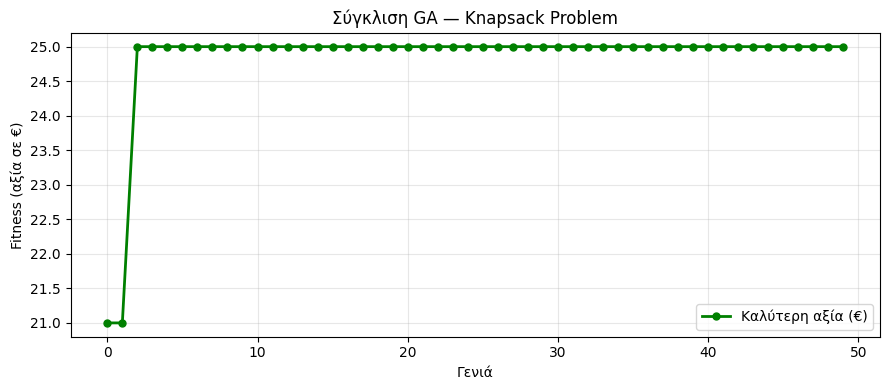

In [8]:
# ── Γράφημα Σύγκλισης Knapsack ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks_hist, 'g-o', markersize=5, linewidth=2, label='Καλύτερη αξία (€)')
ax.set_xlabel('Γενιά')
ax.set_ylabel('Fitness (αξία σε €)')
ax.set_title('Σύγκλιση GA — Knapsack Problem')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 4. Παράδειγμα 3 — Πρόβλημα Πλανόδιου Πωλητή (TSP)

**Πρόβλημα:** Επισκεφθείτε 5 πόλεις (A–E) **ακριβώς μία φορά** και επιστρέψτε στην αφετηρία,  
ελαχιστοποιώντας τη **συνολική απόσταση**.

**Κωδικοποίηση:** Κάθε άτομο = **permutation** χρωμόσωμα — διάταξη των πόλεων.  
Παράδειγμα: `[A, C, B, E, D]` → A→C→B→E→D→A.

**Fitness:** $f = \frac{1}{\text{συνολική απόσταση}}$ — μικρότερη απόσταση = μεγαλύτερο fitness.

**Γιατί δεν κάνει single-point crossover;**  
Το `[A,B,C,D,E]` × `[C,A,E,B,D]` με σημείο τομής μετά τη θέση 2 θα έδινε `[A,B,E,B,D]` — η πόλη B εμφανίζεται δύο φορές! Γι' αυτό χρησιμοποιούμε **Ordered Crossover (OX)**.

### Πώς λειτουργεί το OX;

1. Επιλέγουμε τυχαίο τμήμα από τον P1 (π.χ. θέσεις 1–2)
2. Αντιγράφουμε το τμήμα στο παιδί
3. Συμπληρώνουμε τις υπόλοιπες θέσεις με τη σειρά που εμφανίζονται στον P2, **παραλείποντας** τις πόλεις που υπάρχουν ήδη

| | Θέση 0 | Θέση 1 | Θέση 2 | Θέση 3 | Θέση 4 |
|:---:|:---:|:---:|:---:|:---:|:---:|
| P1 | A | **B** | **C** | D | E |
| P2 | C | A | E | B | D |
| Παιδί | A | **B** | **C** | E | D |

In [9]:
# ── Ορισμός πόλεων ────────────────────────────────────────────────────────

CITIES = {
    'A': (1.0, 1.0),
    'B': (4.0, 3.0),
    'C': (7.0, 1.0),
    'D': (6.0, 5.0),
    'E': (2.0, 5.0),
}
CITY_NAMES = list(CITIES.keys())


def euclidean(a, b):
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)


def total_distance(route):
    n = len(route)
    return sum(euclidean(CITIES[route[i]], CITIES[route[(i+1) % n]])
               for i in range(n))


def fitness_tsp(route):
    return 1.0 / total_distance(route)


# Πίνακας αποστάσεων
print('Πίνακας Αποστάσεων (Euclidean):')
header = '       ' + ''.join(f'{c:>7}' for c in CITY_NAMES)
print(header)
for c1 in CITY_NAMES:
    row = f'{c1:<7}' + ''.join(f'{euclidean(CITIES[c1], CITIES[c2]):>7.2f}'
                               for c2 in CITY_NAMES)
    print(row)

Πίνακας Αποστάσεων (Euclidean):
             A      B      C      D      E
A         0.00   3.61   6.00   6.40   4.12
B         3.61   0.00   3.61   2.83   2.83
C         6.00   3.61   0.00   4.12   6.40
D         6.40   2.83   4.12   0.00   4.00
E         4.12   2.83   6.40   4.00   0.00


In [10]:
# ── OX Crossover & Swap Mutation ─────────────────────────────────────────

def ox_crossover(p1, p2):
    """Ordered Crossover — διατηρεί έγκυρη permutation."""
    n = len(p1)
    start, end = sorted(random.sample(range(n), 2))
    child = [None] * n
    child[start:end+1] = p1[start:end+1]           # αντιγραφή από P1
    remaining = [x for x in p2 if x not in child]  # από P2, χωρίς διπλότυπα
    idx = 0
    for i in range(n):
        if child[i] is None:
            child[i] = remaining[idx]
            idx += 1
    return child


def swap_mutation(route, p_mut=0.2):
    """Ανταλλαγή δύο τυχαίων πόλεων με πιθανότητα p_mut."""
    route = route[:]
    if random.random() < p_mut:
        i, j = random.sample(range(len(route)), 2)
        route[i], route[j] = route[j], route[i]
    return route


# ── Επίδειξη OX ──────────────────────────────────────────────────────────
p1 = ['A', 'B', 'C', 'D', 'E']
p2 = ['C', 'A', 'E', 'B', 'D']
random.seed(7)  # τμήμα 1–2 τυχαία
child = ox_crossover(p1, p2)
print('OX Crossover:')
print(f'  P1    : {p1}')
print(f'  P2    : {p2}')
print(f'  Παιδί : {child}')
print(f'  Απόσταση παιδιού: {total_distance(child):.3f}')

print()
r = ['A', 'C', 'B', 'D', 'E']
random.seed(3)
r_mut = swap_mutation(r, p_mut=1.0)  # εξαναγκάζουμε μετάλλαξη
print('Swap Mutation:')
print(f'  Πριν : {r}   ({total_distance(r):.3f})')
print(f'  Μετά : {r_mut}   ({total_distance(r_mut):.3f}')

OX Crossover:
  P1    : ['A', 'B', 'C', 'D', 'E']
  P2    : ['C', 'A', 'E', 'B', 'D']
  Παιδί : ['A', 'B', 'C', 'E', 'D']
  Απόσταση παιδιού: 24.017

Swap Mutation:
  Πριν : ['A', 'C', 'B', 'D', 'E']   (20.557)
  Μετά : ['A', 'E', 'B', 'D', 'C']   (19.903


In [11]:
# ── Εκτέλεση GA για TSP ───────────────────────────────────────────────────

def run_ga_tsp(pop_size=80, generations=300, p_cross=0.9, p_mut=0.2):
    population = [random.sample(CITY_NAMES, len(CITY_NAMES))
                  for _ in range(pop_size)]
    best_dist_per_gen = []

    for _ in range(generations):
        fitnesses = [fitness_tsp(ind) for ind in population]
        dists     = [total_distance(ind) for ind in population]
        best_dist_per_gen.append(min(dists))

        best_idx = dists.index(min(dists))
        new_pop = [population[best_idx][:]]

        while len(new_pop) < pop_size:
            p1 = roulette_selection(population, fitnesses)
            p2 = roulette_selection(population, fitnesses)
            child = ox_crossover(p1, p2) if random.random() < p_cross else p1[:]
            new_pop.append(swap_mutation(child, p_mut))

        population = new_pop[:pop_size]

    dists = [total_distance(ind) for ind in population]
    best = population[dists.index(min(dists))]
    return best, best_dist_per_gen


random.seed(42)
best_route, tsp_hist = run_ga_tsp()
print('Βέλτιστη Διαδρομή :', ' → '.join(best_route), '→', best_route[0])
print(f'Συνολική Απόσταση : {total_distance(best_route):.3f}')

# Σύγκριση με brute-force (5! = 120 διαδρομές)
from itertools import permutations
all_routes = list(permutations(CITY_NAMES))
opt_dist = min(total_distance(list(r)) for r in all_routes)
print(f'Βέλτιστο (brute-force) : {opt_dist:.3f}')
gap = (total_distance(best_route) - opt_dist) / opt_dist * 100
print(f'Απόκλιση GA από βέλτιστο: {gap:.2f}%')

Βέλτιστη Διαδρομή : A → B → C → D → E → A
Συνολική Απόσταση : 19.457
Βέλτιστο (brute-force) : 19.457
Απόκλιση GA από βέλτιστο: 0.00%


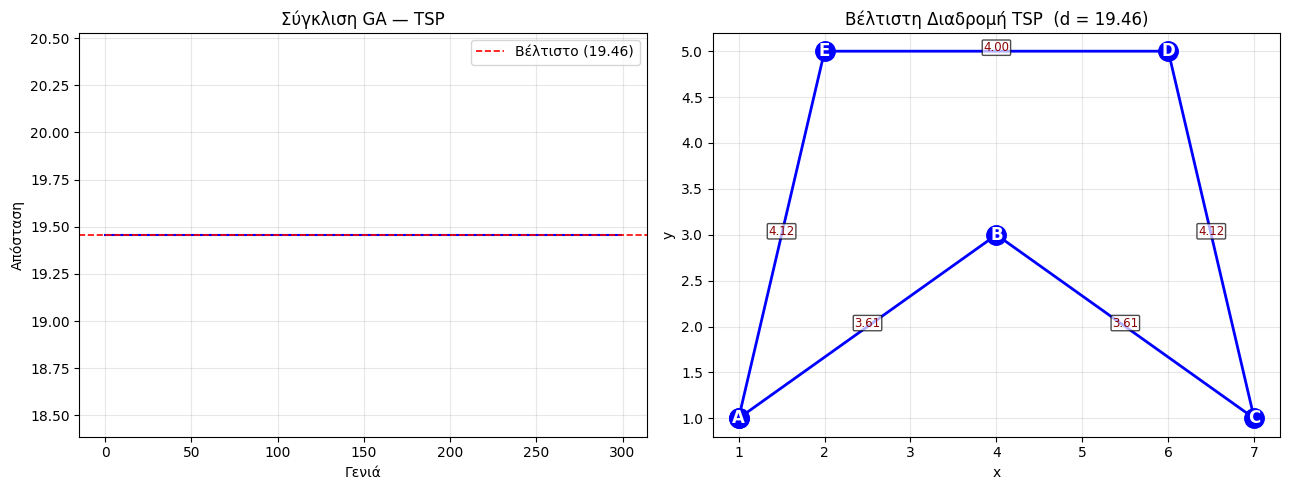

In [12]:
# ── Οπτικοποίηση TSP: Σύγκλιση + Βέλτιστη Διαδρομή ──────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Καμπύλη σύγκλισης
ax1.plot(tsp_hist, 'b-', linewidth=1.5)
ax1.axhline(opt_dist, color='red', linestyle='--', linewidth=1.2, label=f'Βέλτιστο ({opt_dist:.2f})')
ax1.set_xlabel('Γενιά')
ax1.set_ylabel('Απόσταση')
ax1.set_title('Σύγκλιση GA — TSP')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Χάρτης βέλτιστης διαδρομής
route_loop = best_route + [best_route[0]]
xs = [CITIES[c][0] for c in route_loop]
ys = [CITIES[c][1] for c in route_loop]

ax2.plot(xs, ys, 'b-o', markersize=14, linewidth=2, zorder=2)
for city, (x, y) in CITIES.items():
    ax2.annotate(city, (x, y), ha='center', va='center',
                 fontsize=12, fontweight='bold', color='white', zorder=3)

# Αποστάσεις ακμών
for i in range(len(best_route)):
    c1, c2 = route_loop[i], route_loop[i+1]
    mx = (CITIES[c1][0] + CITIES[c2][0]) / 2
    my = (CITIES[c1][1] + CITIES[c2][1]) / 2
    d  = euclidean(CITIES[c1], CITIES[c2])
    ax2.annotate(f'{d:.2f}', (mx, my), fontsize=8.5, color='darkred',
                 ha='center', bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7))

ax2.set_title(f'Βέλτιστη Διαδρομή TSP  (d = {total_distance(best_route):.2f})')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Επίδραση Υπερπαραμέτρων

Ο GA έχει αρκετές **υπερπαραμέτρους** που επηρεάζουν σημαντικά την απόδοσή του:

| Παράμετρος | Πολύ μικρή τιμή | Πολύ μεγάλη τιμή |
|---|---|---|
| `pop_size` | Γρήγορη σύγκλιση, κίνδυνος τοπικού βελτίστου | Αργός, περισσότερη εξερεύνηση |
| `p_mut` | Χωρίς εξερεύνηση → παγίδευση | Τυχαία αναζήτηση → αργή σύγκλιση |
| `p_cross` | Χωρίς ανταλλαγή γνώσης | Υπερβολική ανακάτεμα |
| `generations` | Πρόωρη διακοπή | Σπατάλη χρόνου μετά τη σύγκλιση |

Παρακάτω συγκρίνουμε τρία διαφορετικά **μεγέθη πληθυσμού** και τρία **ποσοστά μετάλλαξης**.

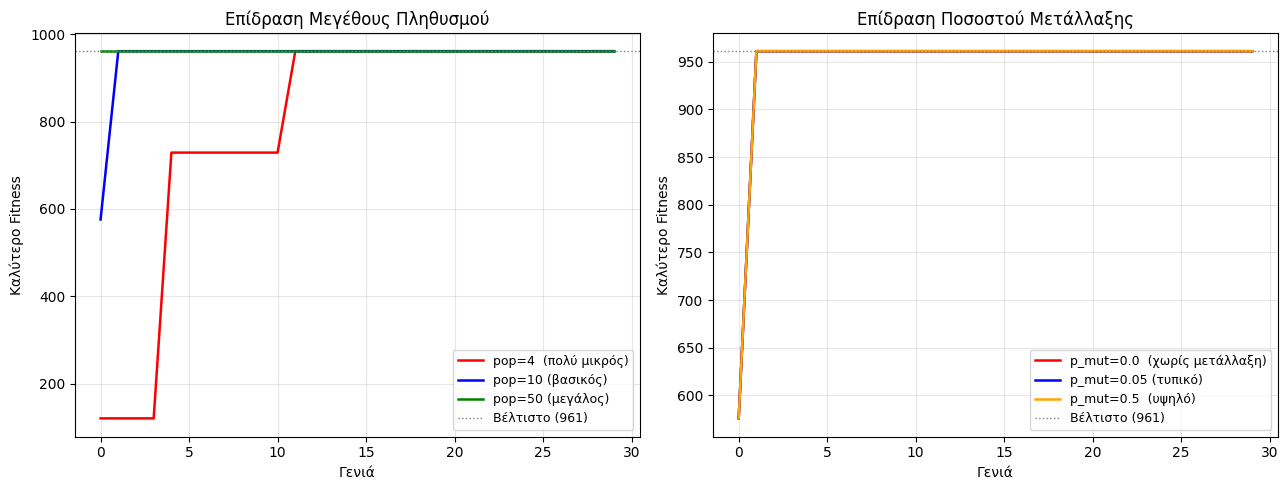

In [13]:
# ── Σύγκριση υπερπαραμέτρων ───────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Α) Μέγεθος πληθυσμού
for pop_size, color, lbl in [
    (4,  'red',   'pop=4  (πολύ μικρός)'),
    (10, 'blue',  'pop=10 (βασικός)'),
    (50, 'green', 'pop=50 (μεγάλος)'),
]:
    random.seed(42)
    _, bh, _ = run_ga_binary(pop_size=pop_size, generations=30)
    ax1.plot(bh, color=color, linewidth=1.8, label=lbl)

ax1.axhline(961, color='gray', linestyle=':', linewidth=1, label='Βέλτιστο (961)')
ax1.set_xlabel('Γενιά')
ax1.set_ylabel('Καλύτερο Fitness')
ax1.set_title('Επίδραση Μεγέθους Πληθυσμού')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Β) Ποσοστό μετάλλαξης
for p_mut, color, lbl in [
    (0.0,  'red',    'p_mut=0.0  (χωρίς μετάλλαξη)'),
    (0.05, 'blue',   'p_mut=0.05 (τυπικό)'),
    (0.5,  'orange', 'p_mut=0.5  (υψηλό)'),
]:
    random.seed(42)
    _, bh, _ = run_ga_binary(pop_size=10, generations=30, p_mut=p_mut)
    ax2.plot(bh, color=color, linewidth=1.8, label=lbl)

ax2.axhline(961, color='gray', linestyle=':', linewidth=1, label='Βέλτιστο (961)')
ax2.set_xlabel('Γενιά')
ax2.set_ylabel('Καλύτερο Fitness')
ax2.set_title('Επίδραση Ποσοστού Μετάλλαξης')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6. Ασκήσεις

**Άσκηση 1 — Επίδραση mutation rate:**  
Τρέξτε τον `run_ga_binary` με `p_mut=0.0` (χωρίς μετάλλαξη) και `p_mut=0.5` (πολύ υψηλό).  
Σχεδιάστε τις καμπύλες σύγκλισης και εξηγήστε: γιατί το `p_mut=0.0` κολλάει σε τοπικό βέλτιστο;

**Άσκηση 2 — Tournament Selection:**  
Υλοποιήστε **tournament selection** ως εναλλακτική της ρουλέτας. Επιλέγει k τυχαία άτομα και επιστρέφει το καλύτερο.

```python
def tournament_selection(population, fitnesses, k=3):
    # Διαλέξτε k τυχαίες θέσεις
    # Επιστρέψτε το άτομο με το μεγαλύτερο fitness
    ...
```

Αντικαταστήστε τη `roulette_selection` με `tournament_selection` στο `run_ga_binary`.  
Συγκρίνετε ταχύτητα σύγκλισης με k=2 και k=5.

**Άσκηση 3 — Knapsack με νέα αντικείμενα:**  
Προσθέστε 3 νέα αντικείμενα στο `ITEMS`, αυξήστε `MAX_WEIGHT = 15 kg`.  
Συμπεριλάβετε ένα «παγιδευτικό» αντικείμενο (μεγάλο βάρος, χαμηλή αξία/kg).  
Ελέγξτε αν ο GA το αποκλείει από τη βέλτιστη λύση.

**Άσκηση 4 — TSP με περισσότερες πόλεις:**  
Προσθέστε 3 επιπλέον πόλεις (F, G, H) στο `CITIES`.  
Αυξήστε `pop_size=150` και `generations=500`.  
Συγκρίνετε το αποτέλεσμα του GA με τον **Nearest Neighbor** (greedy) αλγόριθμο:

```python
def nearest_neighbor(start, cities):
    unvisited = list(cities.keys())
    route = [start]
    unvisited.remove(start)
    while unvisited:
        last = route[-1]
        nearest = min(unvisited, key=lambda c: euclidean(cities[last], cities[c]))
        route.append(nearest)
        unvisited.remove(nearest)
    return route
```

**Άσκηση 5 (προαιρετική) — 2-opt τοπική αναζήτηση:**  
Μετά από κάθε γενιά του TSP GA, εφαρμόστε **2-opt** στο καλύτερο άτομο:  
επιλέξτε τυχαία 2 ακμές και ελέγξτε αν η αντιστροφή του μεταξύ τους τμήματος βελτιώνει τη διαδρομή.  
Αυτός ο συνδυασμός (GA + τοπική αναζήτηση) ονομάζεται **Memetic Algorithm**.

---

## 6. PyGAD — Γενετικοί Αλγόριθμοι με Βιβλιοθήκη

Η **PyGAD** είναι η πιο απλή βιβλιοθήκη GA για Python. Αντί να γράφουμε κάθε τελεστή
από μηδέν, ορίζουμε **μόνο** τη συνάρτηση fitness — τα υπόλοιπα (επιλογή, crossover,
mutation, ελιτισμός) τα διαχειρίζεται η βιβλιοθήκη.

```bash
pip install pygad
```

### Βασικό μοτίβο χρήσης

```python
import pygad

def fitness(ga_instance, solution, solution_idx):
    return evaluate(solution)   # η δική σου λογική

ga = pygad.GA(
    num_generations       = 100,
    num_parents_mating    = 6,
    fitness_func          = fitness,
    sol_per_pop           = 30,     # μέγεθος πληθυσμού
    num_genes             = N,      # μήκος χρωμοσώματος
    gene_type             = int,
    gene_space            = [0, 1], # ή range(0,32) κλπ.
    parent_selection_type = 'rws',  # roulette wheel
    crossover_type        = 'single_point',
    mutation_type         = 'random',
    mutation_percent_genes= 20,
    keep_elitism          = 1,
    random_seed           = 42,
)
ga.run()
solution, fitness_val, _ = ga.best_solution()
```

| Παράμετρος PyGAD | Αντιστοιχεί στο χειροκίνητο GA |
|---|---|
| `sol_per_pop` | `POP_SIZE` |
| `num_generations` | `GENERATIONS` |
| `parent_selection_type='rws'` | `roulette_selection` |
| `crossover_type='single_point'` | `single_point_crossover` |
| `keep_elitism=1` | Ελιτισμός |


In [14]:
pip install pygad


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
# ── PyGAD: Μεγιστοποίηση f(x) = x² ──────────────────────────────────────
# Σύγκριση με Παράδειγμα 1: εδώ το γονίδιο αντιπροσωπεύει
# απευθείας τον ακέραιο x ∈ {0..31} — χωρίς δυαδική κωδικοποίηση.

import random
import pygad
import matplotlib.pyplot as plt

def fitness_fx2_pygad(ga_instance, solution, solution_idx):
    x = int(solution[0])
    return x ** 2


ga_fx2 = pygad.GA(
    num_generations       = 25,
    num_parents_mating    = 4,
    fitness_func          = fitness_fx2_pygad,
    sol_per_pop           = 10,
    num_genes             = 1,
    gene_type             = int,
    gene_space            = range(0, 32),  # x ∈ {0, …, 31}
    parent_selection_type = 'rws',
    crossover_type        = 'single_point',
    mutation_type         = 'random',
    mutation_percent_genes= 50,
    keep_elitism          = 1,
    random_seed           = 42,
)
ga_fx2.run()

sol, fit, _ = ga_fx2.best_solution()
print(f'Βέλτιστο x : {sol[0]}  (αναμένεται 31)')
print(f'f(x) = x²  : {fit}  (αναμένεται 961)')

Βέλτιστο x : 31  (αναμένεται 31)
f(x) = x²  : 961  (αναμένεται 961)


/home/rg/Teaching/uniwa/dss-data-analytics/lab1venv/lib/python3.14/site-packages/pygad/utils/validation.py:690: UserWarning: The percentage of genes to mutate (mutation_percent_genes=50) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


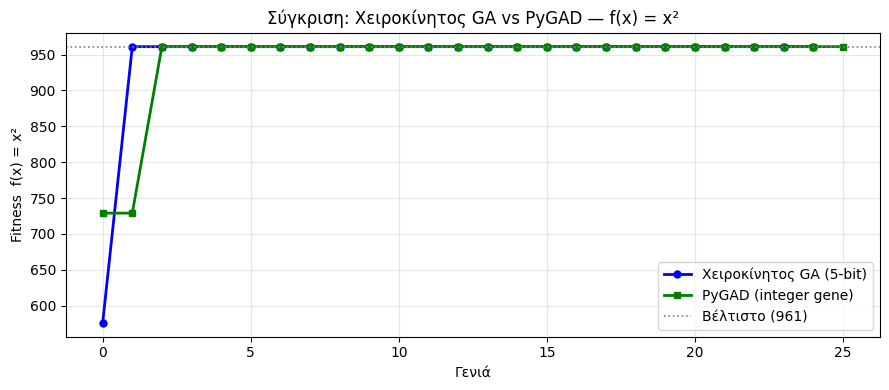

In [16]:
# ── Σύγκριση καμπυλών: χειροκίνητος GA vs PyGAD ─────────────────────────
# Απαιτεί να έχουν τρέξει τα cells της Ενότητας 2 (run_ga_binary)

random.seed(42)
_, manual_hist, _ = run_ga_binary(pop_size=10, generations=25)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(manual_hist,                   'b-o', markersize=5, linewidth=2, label='Χειροκίνητος GA (5-bit)')
ax.plot(ga_fx2.best_solutions_fitness, 'g-s', markersize=5, linewidth=2, label='PyGAD (integer gene)')
ax.axhline(961, color='gray', linestyle=':', linewidth=1.2, label='Βέλτιστο (961)')
ax.set_xlabel('Γενιά')
ax.set_ylabel('Fitness  f(x) = x²')
ax.set_title('Σύγκριση: Χειροκίνητος GA vs PyGAD — f(x) = x²')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ── PyGAD: Knapsack Problem ───────────────────────────────────────────────

import pygad

ITEMS = [
    {'name': 'Laptop',  'weight': 3, 'value': 9},
    {'name': 'Βιβλίο',  'weight': 4, 'value': 5},
    {'name': 'Κάμερα',  'weight': 2, 'value': 7},
    {'name': 'Tablet',  'weight': 5, 'value': 3},
    {'name': 'Ρολόι',   'weight': 1, 'value': 4},
]
MAX_WEIGHT = 10
N_ITEMS = len(ITEMS)


def fitness_knapsack_pygad(ga_instance, solution, solution_idx):
    total_w = sum(ITEMS[i]["weight"] for i in range(N_ITEMS) if solution[i] == 1)
    total_v = sum(ITEMS[i]["value"]  for i in range(N_ITEMS) if solution[i] == 1)
    return float(total_v) if total_w <= MAX_WEIGHT else 0.0


ga_ks = pygad.GA(
    num_generations       = 50,
    num_parents_mating    = 10,
    fitness_func          = fitness_knapsack_pygad,
    sol_per_pop           = 30,
    num_genes             = N_ITEMS,
    gene_type             = int,
    gene_space            = [0, 1],
    parent_selection_type = 'rws',
    crossover_type        = 'single_point',
    mutation_type         = 'random',
    mutation_percent_genes= 20,
    keep_elitism          = 1,
    random_seed           = 42,
)
ga_ks.run()

sol_ks, fit_ks, _ = ga_ks.best_solution()
print(f"Βέλτιστο χρωμόσωμα: {list(sol_ks.astype(int))}")
print(f"Fitness (αξία €)   : {fit_ks}")
print()

total_w, total_v = 0, 0
for i, item in enumerate(ITEMS):
    if sol_ks[i] == 1:
        total_w += item["weight"]
        total_v += item["value"]
        mark = "✓"
    else:
        mark = "✗"
    print(f"  {mark}  {item["name"]:<8}  {item["weight"]} kg  {item["value"]}€")

print(f"Συνολικό βάρος : {total_w} / {MAX_WEIGHT} kg")
print(f"Συνολική αξία  : {total_v} €")

Βέλτιστο χρωμόσωμα: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1)]
Fitness (αξία €)   : 25.0

  ✓  Laptop    3 kg  9€
  ✓  Βιβλίο    4 kg  5€
  ✓  Κάμερα    2 kg  7€
  ✗  Tablet    5 kg  3€
  ✓  Ρολόι     1 kg  4€
Συνολικό βάρος : 10 / 10 kg
Συνολική αξία  : 25 €


/home/rg/Teaching/uniwa/dss-data-analytics/lab1venv/lib/python3.14/site-packages/pygad/utils/validation.py:670: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


Βέλτιστη Διαδρομή : E → A → B → C → D → E
Συνολική Απόσταση : 19.457  (βέλτιστο: 19.457)


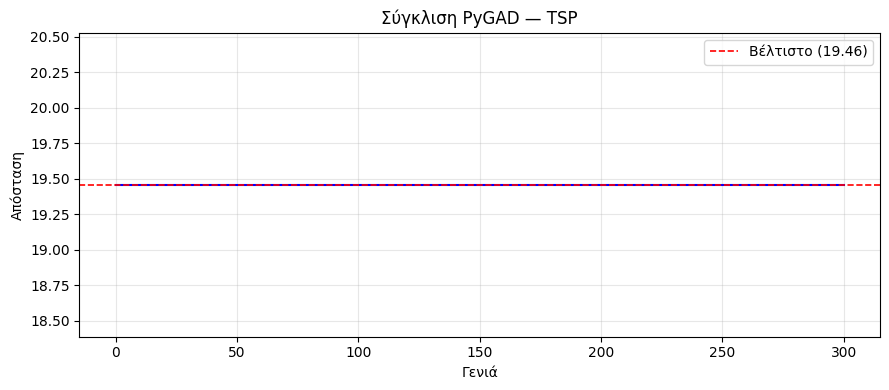

In [18]:
# ── PyGAD: TSP με Custom OX Crossover & Swap Mutation ────────────────────
# PyGAD υποστηρίζει custom τελεστές — ιδανικό για permutation chromosomes.

import pygad
import numpy as np
import matplotlib.pyplot as plt

CITIES_P = {
    'A': (1.0, 1.0), 'B': (4.0, 3.0), 'C': (7.0, 1.0),
    'D': (6.0, 5.0), 'E': (2.0, 5.0),
}
CNAMES = list(CITIES_P.keys())
N_C = len(CNAMES)


def _dist(a, b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)


def route_dist(sol):
    r = [CNAMES[int(i)] for i in sol]
    return sum(_dist(CITIES_P[r[i]], CITIES_P[r[(i+1) % N_C]]) for i in range(N_C))


def fitness_tsp_pygad(ga_instance, solution, solution_idx):
    return 1.0 / route_dist(solution)


def ox_crossover(parents, offspring_size, ga_instance):
    offspring = []
    for _ in range(offspring_size[0]):
        p1 = list(parents[np.random.randint(len(parents))])
        p2 = list(parents[np.random.randint(len(parents))])
        n = len(p1)
        start, end = sorted(np.random.choice(n, 2, replace=False))
        child = [None] * n
        child[start:end+1] = p1[start:end+1]
        remaining = [x for x in p2 if x not in child]
        idx = 0
        for i in range(n):
            if child[i] is None:
                child[i] = remaining[idx]
                idx += 1
        offspring.append(child)
    return np.array(offspring)


def swap_mutation(offspring, ga_instance):
    for i in range(len(offspring)):
        if np.random.random() < 0.2:
            j, k = np.random.choice(len(offspring[i]), 2, replace=False)
            offspring[i][j], offspring[i][k] = offspring[i][k], offspring[i][j]
    return offspring


# Αρχικός πληθυσμός: έγκυρες permutations
np.random.seed(42)
init_pop = [np.random.permutation(N_C).tolist() for _ in range(80)]

ga_tsp_p = pygad.GA(
    num_generations       = 300,
    num_parents_mating    = 20,
    fitness_func          = fitness_tsp_pygad,
    initial_population    = init_pop,
    parent_selection_type = 'rws',
    crossover_type        = ox_crossover,
    mutation_type         = swap_mutation,
    keep_elitism          = 1,
    random_seed           = 42,
)
ga_tsp_p.run()

sol_tsp, fit_tsp, _ = ga_tsp_p.best_solution()
best_route_p = [CNAMES[int(i)] for i in sol_tsp]
best_dist_p  = route_dist(sol_tsp)
print('Βέλτιστη Διαδρομή :', ' → '.join(best_route_p), '→', best_route_p[0])
print(f'Συνολική Απόσταση : {best_dist_p:.3f}  (βέλτιστο: 19.457)')

# ── Γράφημα σύγκλισης ────────────────────────────────────────────────────
dists = [1.0/f if f > 0 else float('inf') for f in ga_tsp_p.best_solutions_fitness]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dists, 'b-', linewidth=1.5)
ax.axhline(19.457, color='red', linestyle='--', linewidth=1.2, label='Βέλτιστο (19.46)')
ax.set_xlabel('Γενιά')
ax.set_ylabel('Απόσταση')
ax.set_title('Σύγκλιση PyGAD — TSP')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


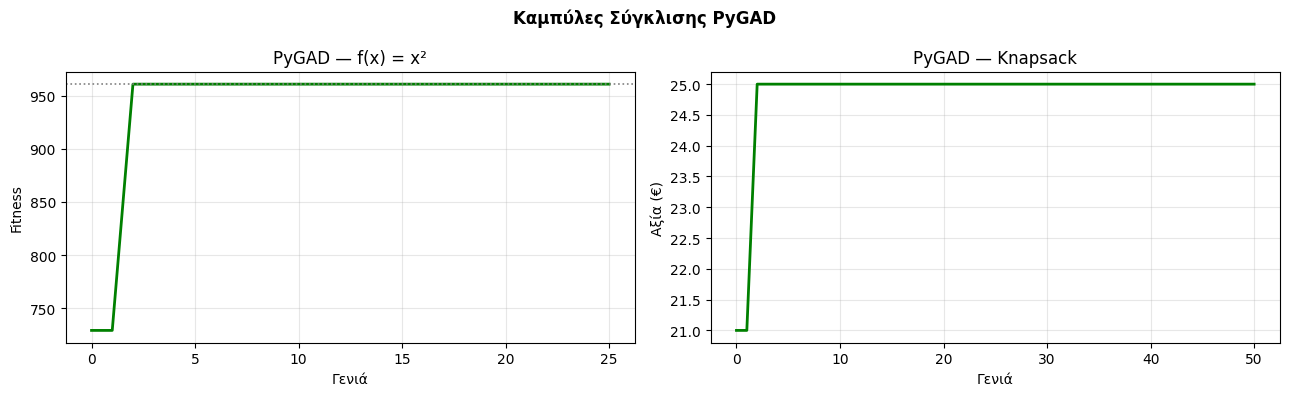

In [19]:
import matplotlib.pyplot as plt

# ── Καμπύλες σύγκλισης PyGAD (built-in ga.best_solutions_fitness) ────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ga_fx2.best_solutions_fitness, 'g-', linewidth=2)
ax1.axhline(961, color='gray', linestyle=':', linewidth=1.2)
ax1.set_title('PyGAD — f(x) = x²')
ax1.set_xlabel('Γενιά')
ax1.set_ylabel('Fitness')
ax1.grid(True, alpha=0.3)

ax2.plot(ga_ks.best_solutions_fitness, 'g-', linewidth=2)
ax2.set_title('PyGAD — Knapsack')
ax2.set_xlabel('Γενιά')
ax2.set_ylabel('Αξία (€)')
ax2.grid(True, alpha=0.3)

plt.suptitle('Καμπύλες Σύγκλισης PyGAD', fontweight='bold')
plt.tight_layout()
plt.show()

---

## 7. PyGAD — Πραγματικό Παράδειγμα: Βελτιστοποίηση Προγράμματος Βαρδιών

### 7.1 Το Πρόβλημα

Μια καφετέρια λειτουργεί **Δευτέρα–Παρασκευή** με δύο βάρδιες:

| Βάρδια | Ώρες | Κωδικός |
|--------|------|---------|
| Πρωί | 07:00–15:00 | `0` |
| Απόγευμα | 14:00–22:00 | `1` |
| Ρεπό | — | `2` |

Έχουμε **6 υπαλλήλους**. Οι κανόνες:
- Κάθε βάρδια (πρωί & απόγευμα) χρειάζεται **τουλάχιστον 2 υπαλλήλους** ανά ημέρα
- Κάθε υπάλληλος κάνει **ακριβώς 1 ρεπό** την εβδομάδα

Ερώτηση: πώς κατανέμουμε τις βάρδιες ώστε να ικανοποιούνται όλοι οι κανόνες;

**Γιατί GA;** Υπάρχουν 3 επιλογές ανά (υπάλληλος, ημέρα) και 30 θέσεις συνολικά
→ **3³⁰ ≈ 200 τρισεκατομμύρια** πιθανά προγράμματα. Αδύνατο να τα ελέγξουμε όλα.

---

### 7.2 Κωδικοποίηση GA

Κάθε χρωμόσωμα είναι μια **λίστα από 30 ακεραίους** (6 υπάλληλοι × 5 μέρες),
όπου κάθε τιμή είναι 0, 1 ή 2:

```
Χρωμόσωμα (30 γονίδια):
[ 0, 1, 2, 0, 1,   1, 0, 1, 0, 2,   0, 0, 1, 2, 1,   1, 2, 0, 1, 0,   0, 1, 0, 1, 2,   2, 0, 1, 0, 1 ]
  ──────────────   ──────────────   ──────────────   ──────────────   ──────────────   ──────────────
     Υπ. 1             Υπ. 2             Υπ. 3             Υπ. 4             Υπ. 5             Υπ. 6
  Δ  Τ  Τ  Π  Π    Δ  Τ  Τ  Π  Π    ...
  0=Πρ 1=Απ 2=Ρε
```

Ο PyGAD παράγει αρχικά **τυχαίες τιμές** από το `gene_space=[0, 1, 2]`.
Στη συνέχεια τις εξελίσσει μέσω crossover και mutation.

Για να διαβάσουμε το πρόγραμμα, κάνουμε `reshape(6, 5)`:

```
         Δευ  Τρι  Τετ  Πεμ  Παρ
Υπ. 1:  [ 0,   1,   2,   0,   1 ]  → Πρ, Απ, Ρεπό, Πρ, Απ
Υπ. 2:  [ 1,   0,   1,   0,   2 ]  → Απ, Πρ, Απ, Πρ, Ρεπό
  ...
```

---

### 7.3 Fitness Function — Ποινές (Penalty-based)

Σε προβλήματα με **περιορισμούς** (constraints), η fitness function συνήθως
μετρά πόσο «κακά» παραβιάζονται οι κανόνες και επιστρέφει **ποινή**:

```
Ποινή = 0   →  όλοι οι κανόνες ικανοποιούνται  ← ζητούμενο
Ποινή > 0   →  κάποιος κανόνας παραβιάστηκε
```

Εδώ ορίζουμε δύο ποινές:

**Π1 — Κάλυψη:** αν μια βάρδια μιας ημέρας έχει λιγότερους από 2 υπαλλήλους:
```
ποινή += (2 − πλήθος) × 10   για κάθε έλλειψη
```

**Π2 — Ρεπό:** αν ένας υπάλληλος έχει 0 ή 2+ ρεπό (αντί για ακριβώς 1):
```
ποινή += |ρεπό_υπαλλήλου − 1| × 8   για κάθε υπάλληλο
```

Επειδή ο PyGAD **μεγιστοποιεί**, ορίζουμε:
```python
fitness = −ποινή
```
Άρα το βέλτιστο χρωμόσωμα έχει fitness = 0 (ποινή = 0).

In [ ]:
# ── PyGAD: Βελτιστοποίηση Προγράμματος Βαρδιών ──────────────────────────

import pygad
import numpy as np

N_EMPL  = 6
N_DAYS  = 5
DAYS    = ['Δευ', 'Τρι', 'Τετ', 'Πεμ', 'Παρ']
LABELS  = ['Πρωί', 'Απόγ', 'Ρεπό']

MIN_COV    = 2   # ελάχιστοι υπάλληλοι ανά βάρδια ανά ημέρα
TARGET_OFF = 1   # ρεπό ανά υπάλληλο/εβδομάδα


def decode(chrom):
    """30 ακέραιοι → πίνακας 6×5 (υπάλληλοι × ημέρες)."""
    return np.array(chrom, dtype=int).reshape(N_EMPL, N_DAYS)


def fitness_shift(ga_instance, solution, solution_idx):
    s = decode(solution)
    penalty = 0

    # Π1: κάλυψη — κάθε βάρδια (0=πρωί, 1=απόγ) πρέπει να έχει ≥ MIN_COV
    for d in range(N_DAYS):
        for shift in [0, 1]:
            count = np.sum(s[:, d] == shift)
            if count < MIN_COV:
                penalty += (MIN_COV - count) * 10   # +10 ανά «κενή» θέση

    # Π2: ρεπό — κάθε υπάλληλος πρέπει να έχει ακριβώς TARGET_OFF ρεπό
    for e in range(N_EMPL):
        off = np.sum(s[e, :] == 2)
        penalty += abs(off - TARGET_OFF) * 8        # +8 για κάθε επιπλέον/ελλιπές

    return -penalty   # μεγιστοποίηση: fitness=0 σημαίνει μηδενική ποινή


ga_shift = pygad.GA(
    num_generations        = 500,
    num_parents_mating     = 15,
    fitness_func           = fitness_shift,
    sol_per_pop            = 100,
    num_genes              = N_EMPL * N_DAYS,   # 30 γονίδια
    gene_type              = int,
    gene_space             = [0, 1, 2],          # μόνο έγκυρες τιμές βάρδιας
    mutation_type          = 'random',
    mutation_percent_genes = 20,
    crossover_type         = 'single_point',
    keep_elitism           = 5,
    random_seed            = 42,
)

ga_shift.run()

# ── Εξαγωγή & εμφάνιση βέλτιστης λύσης ──────────────────────────────────
best_sol, best_fitness, _ = ga_shift.best_solution()
schedule = decode(best_sol)
penalty  = int(-best_fitness)

print('═' * 42)
print('  ΒΕΛΤΙΣΤΟ ΠΡΟΓΡΑΜΜΑ ΒΑΡΔΙΩΝ')
print('═' * 42)
header = f"{'':10}" + ''.join(f'{d:7}' for d in DAYS)
print(header)
print('─' * 42)
for e in range(N_EMPL):
    row = f'  Υπ.{e+1}    ' + ''.join(f'{LABELS[s]:7}' for s in schedule[e])
    print(row)
print('─' * 42)

print('\nΚάλυψη ανά ημέρα:')
print(f"{'':12}" + ''.join(f'{d:7}' for d in DAYS))
for shift_id, sname in enumerate(['Πρωί', 'Απόγ']):
    counts = [np.sum(schedule[:, d] == shift_id) for d in range(N_DAYS)]
    ok = all(c >= MIN_COV for c in counts)
    row = f'  {sname:10}' + ''.join(f'{c:7}' for c in counts)
    print(row + ('  ✓' if ok else '  ✗ ΕΛΛΕΙΨΗ'))

offs = [np.sum(schedule[e, :] == 2) for e in range(N_EMPL)]
off_ok = all(o == TARGET_OFF for o in offs)
print(f'\nΡεπό/υπάλληλο: {offs}  {"✓" if off_ok else "✗"}')
print(f'\nΣυνολική ποινή: {penalty}  {"→ Βέλτιστο!" if penalty == 0 else "→ Μερική λύση"}')

In [ ]:
# ── Οπτικοποίηση προγράμματος βαρδιών ───────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap προγράμματος
COLORS = {0: '#4472C4', 1: '#ED7D31', 2: '#D9D9D9'}   # μπλε / πορτοκαλί / γκρι

for e in range(N_EMPL):
    for d in range(N_DAYS):
        val = schedule[e, d]
        rect = plt.Rectangle([d, N_EMPL - 1 - e], 1, 1,
                              color=COLORS[val], ec='white', lw=2)
        ax1.add_patch(rect)
        ax1.text(d + 0.5, N_EMPL - 0.5 - e, LABELS[val],
                 ha='center', va='center', fontsize=10, fontweight='bold',
                 color='white' if val < 2 else '#888888')

ax1.set_xlim(0, N_DAYS)
ax1.set_ylim(0, N_EMPL)
ax1.set_xticks(np.arange(N_DAYS) + 0.5)
ax1.set_xticklabels(DAYS, fontsize=11)
ax1.set_yticks(np.arange(N_EMPL) + 0.5)
ax1.set_yticklabels([f'Υπ. {N_EMPL - e}' for e in range(N_EMPL)], fontsize=11)
ax1.set_title('Βέλτιστο Πρόγραμμα Βαρδιών', fontsize=12, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#4472C4', label='Πρωί  (07:00–15:00)'),
    mpatches.Patch(color='#ED7D31', label='Απόγευμα (14:00–22:00)'),
    mpatches.Patch(color='#D9D9D9', label='Ρεπό'),
]
ax1.legend(handles=legend_patches, loc='upper right', fontsize=9)

# 2. Καμπύλη σύγκλισης
fitness_hist = ga_shift.best_solutions_fitness
ax2.plot(fitness_hist, color='steelblue', linewidth=2)
ax2.axhline(0, color='tomato', linestyle='--', linewidth=1.5,
            label='Στόχος: ποινή = 0')
ax2.set_xlabel('Γενιά', fontsize=11)
ax2.set_ylabel('Fitness  (= −ποινή)', fontsize=11)
ax2.set_title('Σύγκλιση GA', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('PyGAD — Βελτιστοποίηση Βαρδιών',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Ανάλυση Αποτελεσμάτων

#### Τι λέει η εκτύπωση;

Το πρόγραμμα δείχνει ποια βάρδια κάνει κάθε υπάλληλος κάθε μέρα.
Ο έλεγχος κάλυψης επαληθεύει ότι κάθε βάρδια έχει ≥ 2 υπαλλήλους.

Αν η **συνολική ποινή = 0**, ο GA βρήκε **εφικτό πρόγραμμα** που ικανοποιεί
όλους τους κανόνες. Αν ποινή > 0, βρήκε την καλύτερη δυνατή προσέγγιση
(ελάχιστες παραβιάσεις) — χρησιμοποιήσαμε πάντως αρκετές γενιές
(500) και μεγάλο πληθυσμό (100) ώστε να έχουμε ποινή = 0.

---

#### Τι δείχνει κάθε γράφημα;

**Heatmap (αριστερά)**  
Κάθε κελί = (υπάλληλος, ημέρα). Χρώμα:
- **Μπλε** = Πρωινή βάρδια
- **Πορτοκαλί** = Απογευματινή βάρδια
- **Γκρι** = Ρεπό

Με μια ματιά βλέπουμε αν κάθε στήλη (ημέρα) έχει ικανοποιητική κάλυψη
και αν κάθε γραμμή (υπάλληλος) έχει ακριβώς ένα γκρι κελί.

**Καμπύλη σύγκλισης (δεξιά)**  
Ο κατακόρυφος άξονας είναι το fitness (= −ποινή):
- Στην αρχή (~γενιά 0): τυχαία προγράμματα με μεγάλη ποινή → fitness πολύ αρνητικό
- Σταδιακή άνοδος: ο GA βελτιώνει το πρόγραμμα γενιά-γενιά
- Όταν φτάσει στο **0** (κόκκινη γραμμή): βρέθηκε εφικτό πρόγραμμα

---

#### Γιατί penalty-based και όχι απευθείας αναζήτηση;

Θα μπορούσαμε να απορρίπτουμε τα χρωμόσωμα που παραβιάζουν κανόνες
(«death penalty»). Το πρόβλημα: **σχεδόν όλα τα τυχαία χρωμόσωμα**
παραβιάζουν κάτι, οπότε ο GA δεν έχει τίποτα να συγκρίνει στις πρώτες γενιές.

Με ποινές, κάθε χρωμόσωμα παίρνει βαθμό ανάλογα με το **πόσο κοντά** είναι
στη λύση — ο GA «βλέπει» κατεύθυνση προς τη βελτίωση ακόμα και σε κακές λύσεις.